# Loan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "loan_data.csv"

## Read the file

In [2]:
df = pd.read_csv(FILE)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Shape (rows, columns)

In [3]:
df.shape

(45000, 14)

## Columns

In [4]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

## Info (dtypes & non-null counts)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Target balance (loan_status)

In [6]:
df["loan_status"].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

## Descriptive statistics (numeric columns)

Mean, median, mode, min/max, quartiles (Q1/Q3) and standard deviation for every numeric column.

In [7]:
def describe_full(frame):
    num = frame.select_dtypes("number")
    return pd.DataFrame({
        "mean":   num.mean(),
        "median": num.median(),
        "mode":   num.mode().iloc[0],
        "min":    num.min(),
        "Q1":     num.quantile(0.25),
        "Q3":     num.quantile(0.75),
        "max":    num.max(),
        "std":    num.std(),
    }).round(2)

describe_full(df)

,mean,median,mode,min,Q1,Q3,max,std
person_age,27.76,26.00,23.00,20.00,24.00,30.00,144.00,6.05
person_income,80319.05,67048.00,8000.00,8000.00,47204.00,95789.25,7200766.00,80422.50
person_emp_exp,5.41,4.00,0.00,0.00,1.00,8.00,125.00,6.06
loan_amnt,9583.16,8000.00,10000.00,500.00,5000.00,12237.25,35000.00,6314.89
loan_int_rate,11.01,11.01,11.01,5.42,8.59,12.99,20.00,2.98
loan_percent_income,0.14,0.12,0.08,0.00,0.07,0.19,0.66,0.09
cb_person_cred_hist_length,5.87,4.00,4.00,2.00,3.00,8.00,30.00,3.88
credit_score,632.61,640.00,658.00,390.00,601.00,670.00,850.00,50.44
loan_status,0.22,0.00,0.00,0.00,0.00,0.00,1.00,0.42


## 1. Pairplots

Pairwise scatter plots of every numeric feature, coloured by `loan_status` (1 = approved).
The diagonal shows each feature's distribution. Stray points far from the main cloud (e.g. on the
`person_age` and `person_emp_exp` rows/columns) are the impossible outliers.

*Note: rendering ~45k points across the grid takes ~20-30 seconds.*

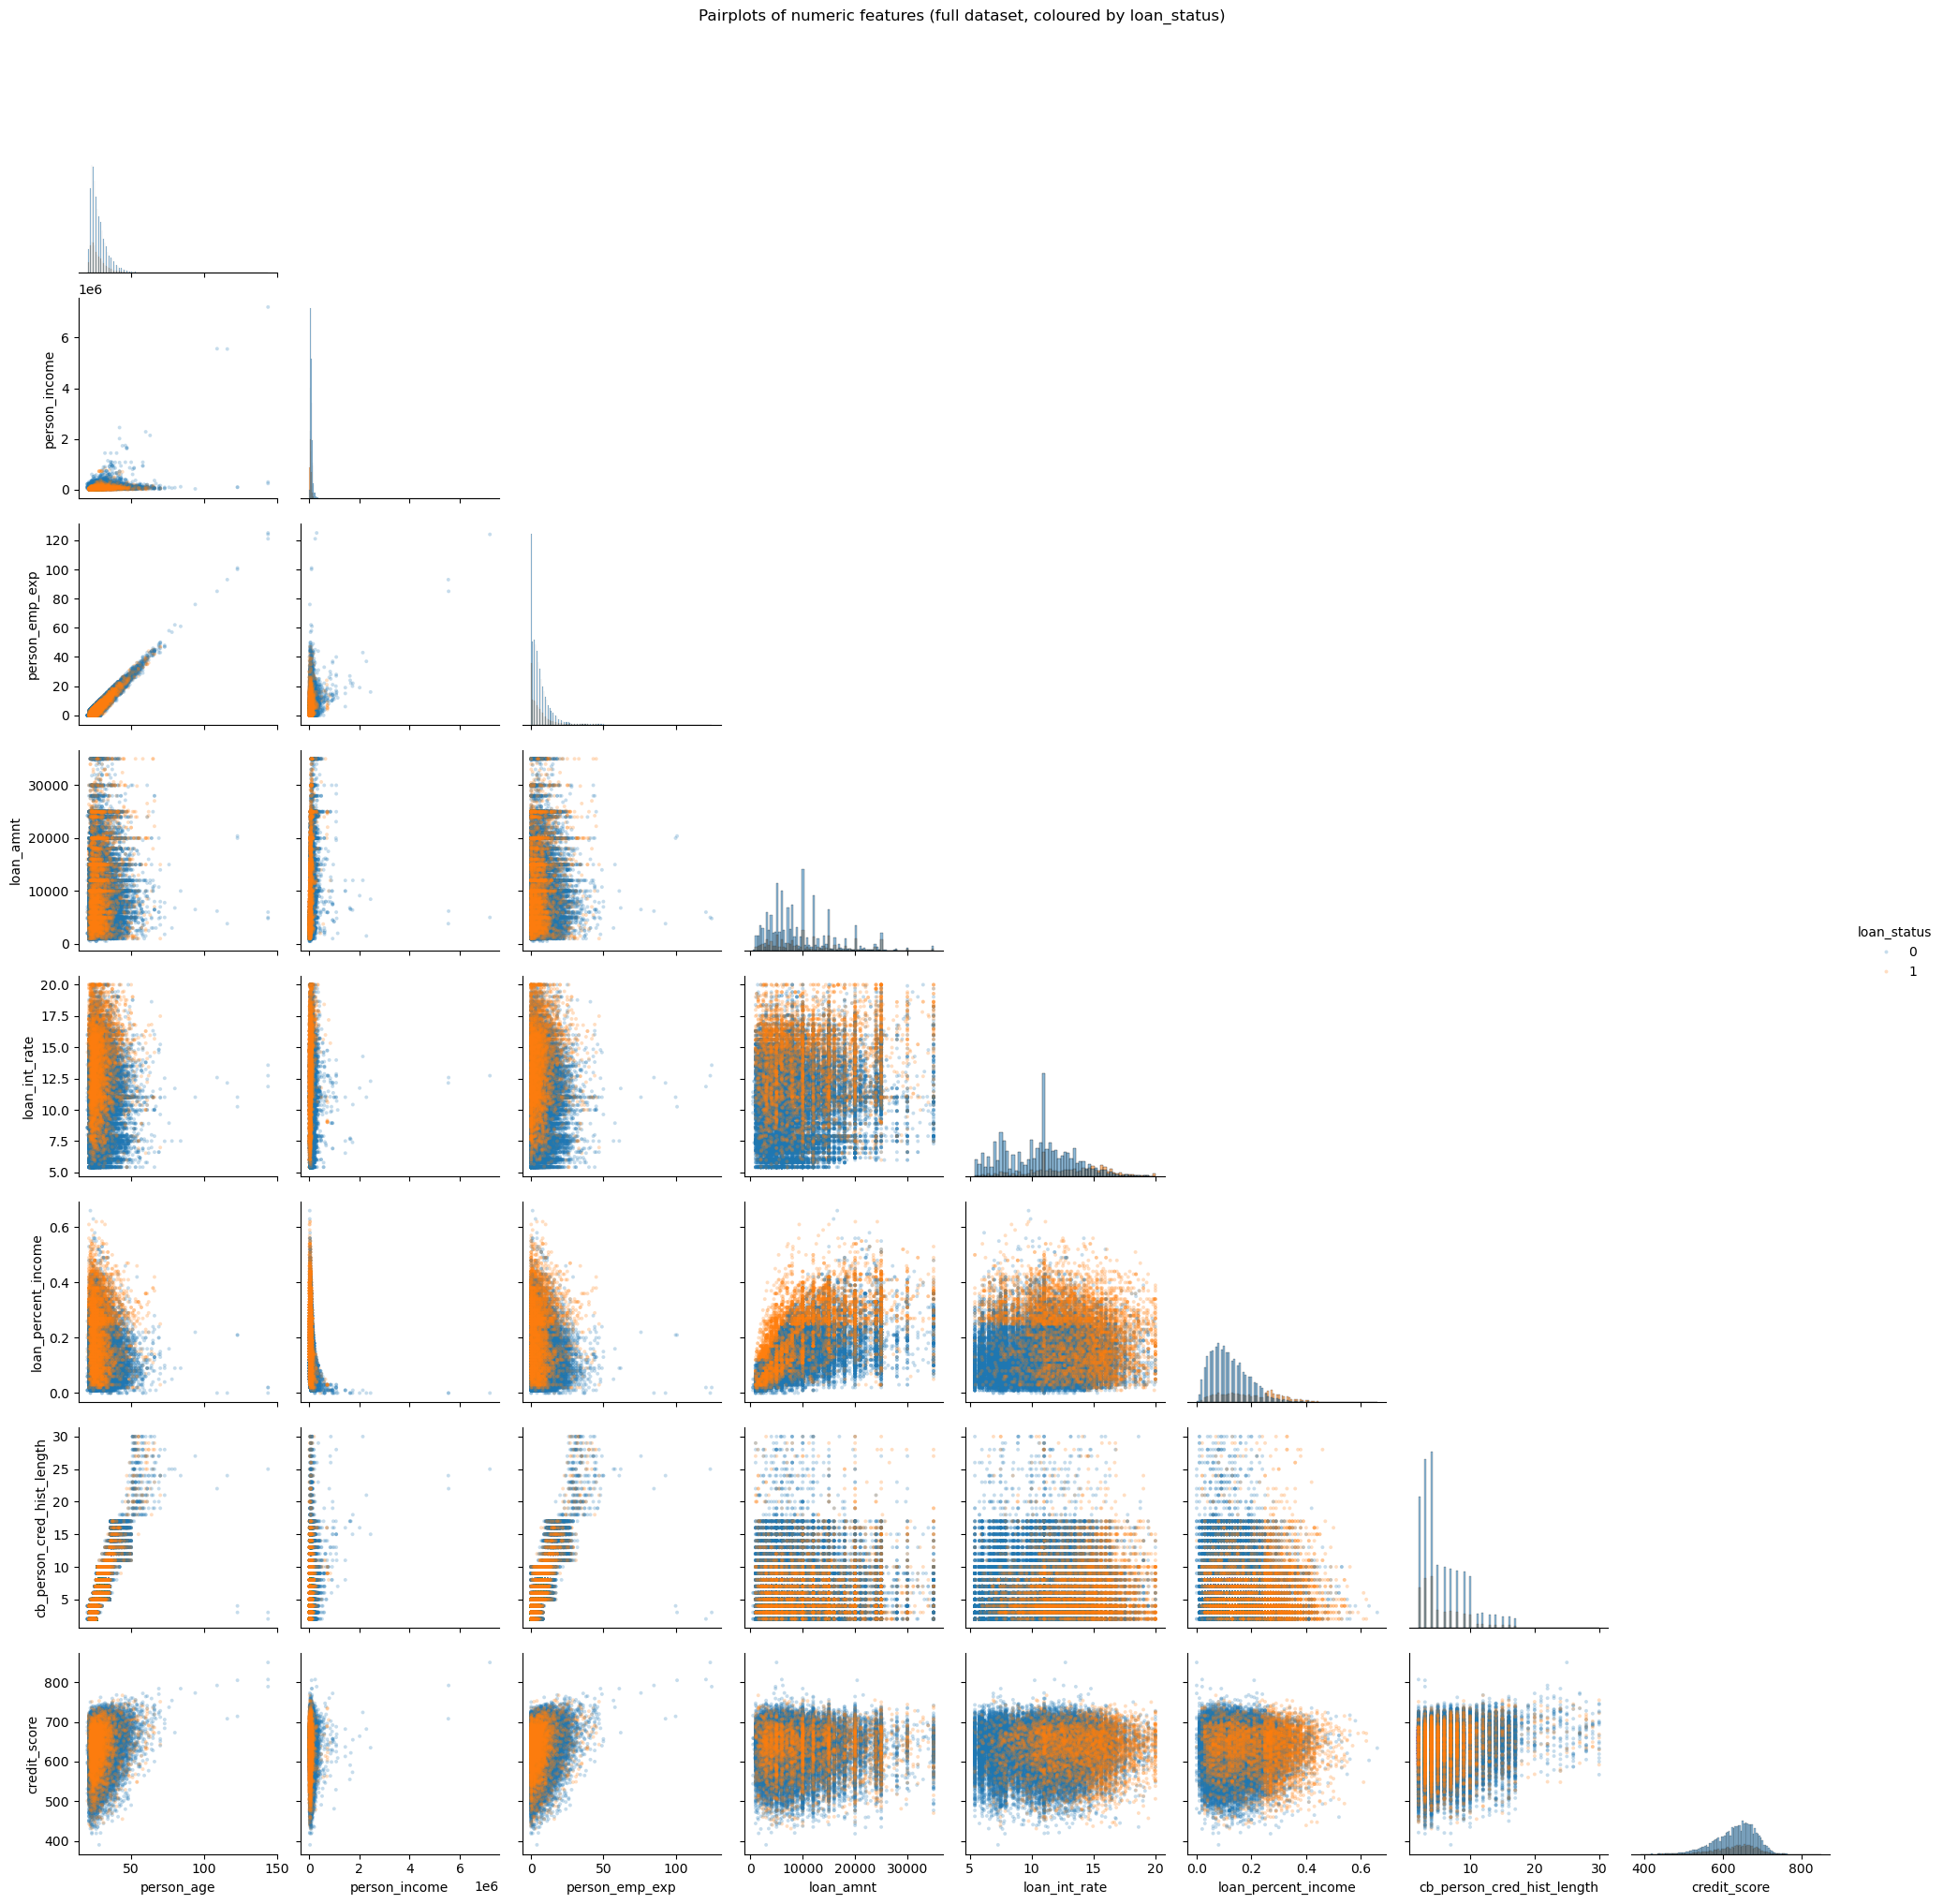

In [8]:
features = [
    "person_age", "person_income", "person_emp_exp", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "credit_score",
]

grid = sns.pairplot(
    df,
    vars=features,
    hue="loan_status",
    corner=True,                 # lower triangle only — cleaner & faster
    diag_kind="hist",
    plot_kws=dict(s=8, alpha=0.25, edgecolor="none"),
)
grid.figure.suptitle("Pairplots of numeric features (full dataset, coloured by loan_status)", y=1.02)
plt.show()

## 2. Mean vs median per column (outlier view)

One boxplot per numeric column with the **mean (red dashed)** and **median (green solid)** drawn and
labelled. Outliers appear as individual points beyond the whiskers, and a large gap between the mean
and median line signals a skewed column being pulled by those outliers.

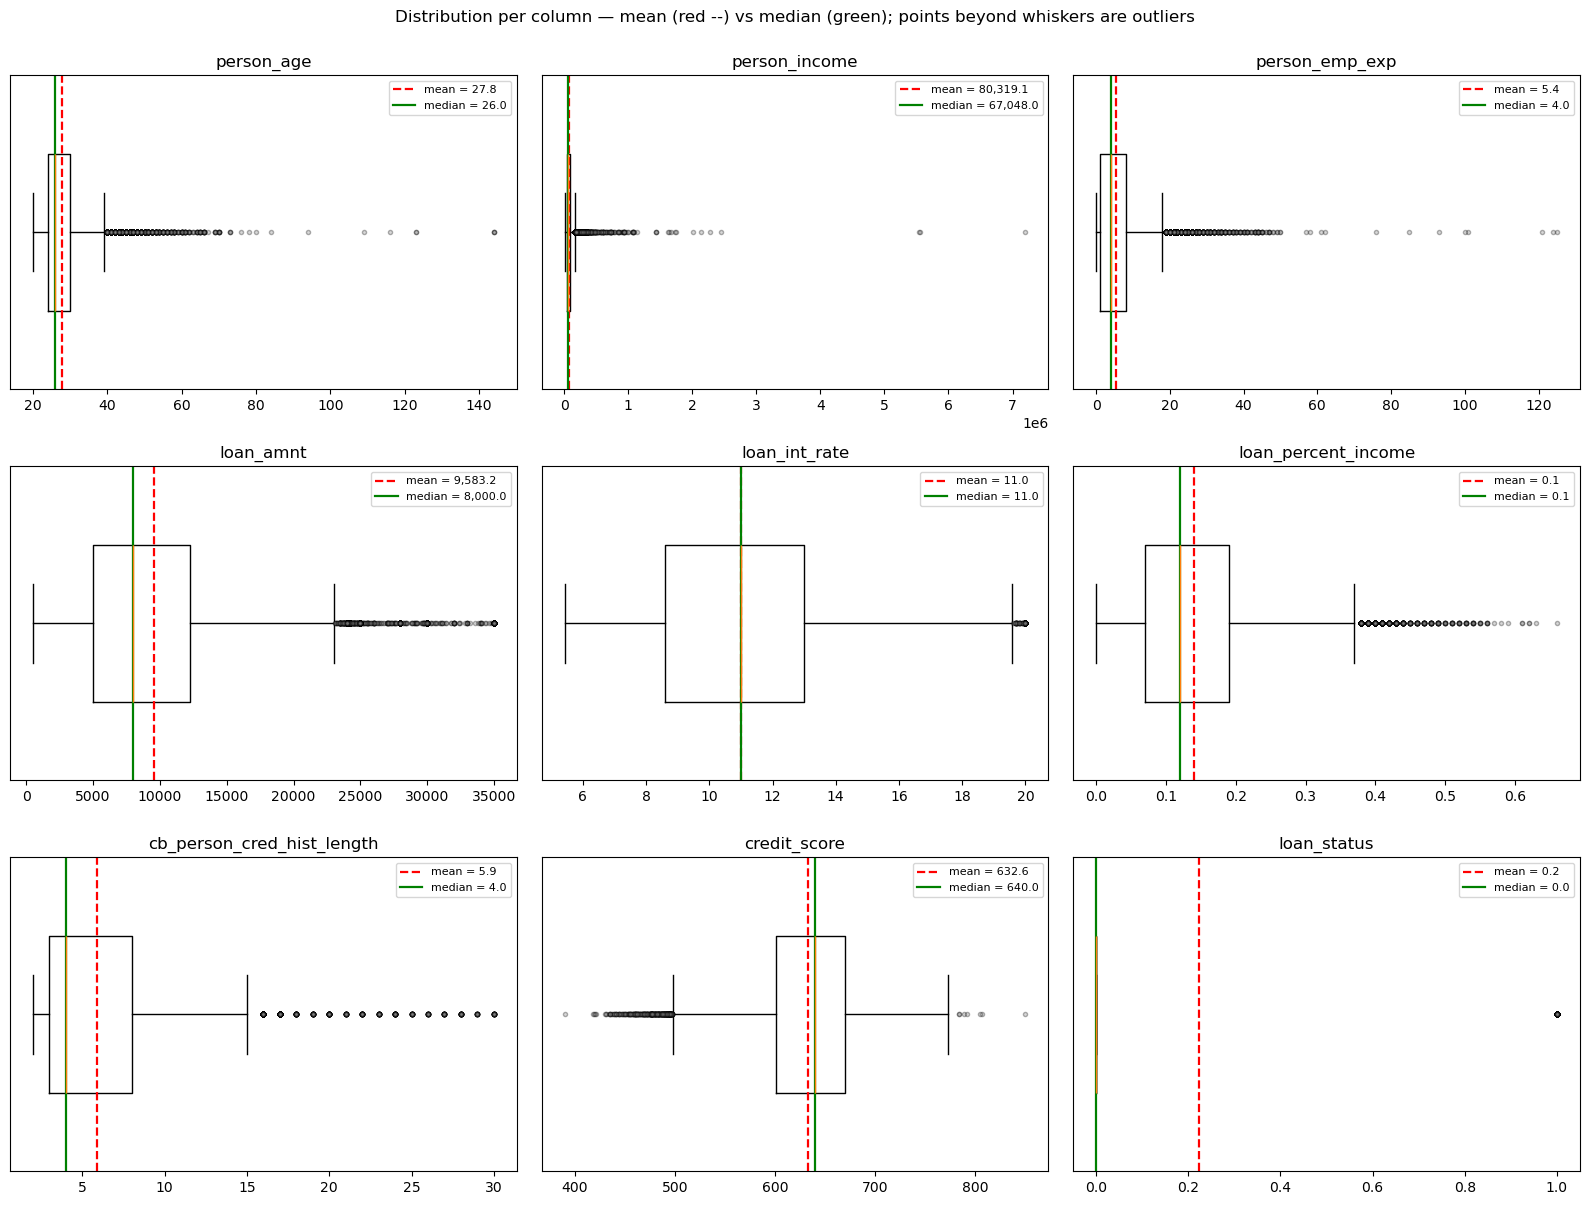

In [9]:
num_cols = df.select_dtypes("number").columns
ncols = 3
nrows = -(-len(num_cols) // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    ax.boxplot(
        data, vert=False, widths=0.5,
        flierprops=dict(marker="o", markersize=3, markerfacecolor="gray", alpha=0.3),
    )
    mean_v, median_v = data.mean(), data.median()
    ax.axvline(mean_v,   color="red",   linestyle="--", linewidth=1.6, label=f"mean = {mean_v:,.1f}")
    ax.axvline(median_v, color="green", linestyle="-",  linewidth=1.6, label=f"median = {median_v:,.1f}")
    ax.set_title(col)
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8)

for ax in axes[len(num_cols):]:      # hide any empty subplot
    ax.axis("off")

fig.suptitle("Distribution per column — mean (red --) vs median (green); points beyond whiskers are outliers", y=1.0)
fig.tight_layout()
plt.show()

## Data cleaning — remove impossible outliers

Two columns contain physically impossible values:

- **`person_age`** reaches 144 (a handful of rows above 100).
- **`person_emp_exp`** reaches 125 years of work experience (rows above 60).

We drop rows where `person_age > 100` **or** `person_emp_exp > 60`, and report how many were removed.

In [12]:
bad = (df["person_age"] > 100) | (df["person_emp_exp"] > 60)
print("Rows flagged as impossible:", int(bad.sum()))

df_clean = df[~bad].reset_index(drop=True)
print("Before:", df.shape)
print("After :", df_clean.shape)

Rows flagged as impossible: 10
Before: (45000, 14)
After : (44990, 14)


# Does a higher value change the default rate?

In [10]:
pairs = ["credit_score", "person_income", "loan_percent_income"]

corr = pd.DataFrame({
    "pearson_r": [df[c].corr(df["loan_status"]) for c in pairs],
}, index=pairs).round(3)

print("Overall approval rate (loan_status==1): %.1f%%\n" % (100 * df["loan_status"].mean()))
corr

Overall approval rate (loan_status==1): 22.2%



,pearson_r
credit_score,-0.008
person_income,-0.136
loan_percent_income,0.385


### What the three pairs show

- **credit_score → approval:** Pearson r ≈ **-0.008** (essentially zero). The approval rate stays flat at ~21–23% across every decile — credit score looks unrelated *here* (we'll see later it was being masked).
- **person_income → approval:** Pearson r ≈ **-0.136** (negative). The approval rate **falls** as income rises — from ~48% in the lowest decile to ~9% in the highest.
- **loan_percent_income → approval:** Pearson r ≈ **+0.385** (the strongest of the three). The approval rate **climbs** steeply — from ~10% to ~71% — as the loan-to-income ratio grows.

*These two directions (higher income → fewer approvals, higher debt-to-income → more approvals) run opposite to typical lending — a quirk of this dataset, reported as-is.*

## Descriptive statistics after cleaning

Note how the `person_age` and `person_emp_exp` maxima drop to realistic values.

In [13]:
describe_full(df_clean)

,mean,median,mode,min,Q1,Q3,max,std
person_age,27.74,26.00,23.00,20.00,24.00,30.00,78.00,5.89
person_income,79908.83,67045.50,8000.00,8000.00,47195.75,95777.00,2448661.00,63323.59
person_emp_exp,5.39,4.00,0.00,0.00,1.00,8.00,58.00,5.91
loan_amnt,9583.30,8000.00,10000.00,500.00,5000.00,12237.75,35000.00,6314.98
loan_int_rate,11.01,11.01,11.01,5.42,8.59,12.99,20.00,2.98
loan_percent_income,0.14,0.12,0.08,0.00,0.07,0.19,0.66,0.09
cb_person_cred_hist_length,5.87,4.00,4.00,2.00,3.00,8.00,30.00,3.87
credit_score,632.58,640.00,658.00,390.00,601.00,670.00,784.00,50.39
loan_status,0.22,0.00,0.00,0.00,0.00,0.00,1.00,0.42


# Statistical significance & confounding check

Two follow-up questions on the three pairs above: **(1)** are the Pearson correlations statistically
significant, and do they survive outlier removal? **(2)** could leaving out the categorical columns
(`person_gender`, `person_education`, `loan_intent`, `person_home_ownership`) be distorting them?

This section runs after cleaning so both `df` (full) and `df_clean` are available.

## 1. Significance (p-values) — full vs cleaned data

`scipy.stats.pearsonr` returns the p-value for each correlation. A small p-value (< 0.05) means the
relationship is unlikely to be due to chance. We compute it on the **full** and **cleaned** data to
confirm the conclusions survive outlier removal.

In [14]:
from scipy import stats
from IPython.display import display

def corr_pvalues(d):
    out = {}
    for c in pairs:
        r, p = stats.pearsonr(d[c], d["loan_status"])
        out[c] = {"pearson_r": round(r, 4), "p_value": p}
    return pd.DataFrame(out).T

print(f"Full data (n={len(df)}):")
display(corr_pvalues(df))
print(f"\nCleaned data (n={len(df_clean)}):")
display(corr_pvalues(df_clean))

Full data (n=45000):


,pearson_r,p_value
credit_score,-0.0076,1.047627e-01
person_income,-0.1358,3.483099e-184
loan_percent_income,0.3849,0.000000e+00



Cleaned data (n=44990):


,pearson_r,p_value
credit_score,-0.0073,1.199193e-01
person_income,-0.1690,1.362753e-285
loan_percent_income,0.3849,0.000000e+00


**p-value read-out.**

- **credit_score:** p ≈ 0.10 → **not significant**. Its near-zero correlation is real noise, not a weak signal.
- **person_income:** p ≈ 1e-184 → overwhelmingly significant. On cleaned data the Pearson r *strengthens* from **-0.136 to -0.169** (the extreme high incomes were flattening the linear fit).
- **loan_percent_income:** p ≈ 0 → overwhelmingly significant, and **identical** on cleaned data (its outliers were never removed).

So cleaning the impossible age/experience rows leaves every conclusion intact — it only sharpens income's correlation.

## 2. Do the omitted categoricals distort the results? (confounding check)

A pairwise correlation only measures the **marginal** relationship — it can't tell a feature's own effect
apart from that of correlated variables we left out. To test this we fit two logistic regressions (numeric
features standardized so their coefficients are comparable):

- **Model A** — the three numeric features only.
- **Model B** — same three features **plus** the four categoricals.

If a numeric coefficient changes a lot from A to B, part of its apparent effect was really a confounder.

In [15]:
import statsmodels.formula.api as smf

d = df.copy()
for c in pairs:
    d[c + "_z"] = (d[c] - d[c].mean()) / d[c].std()   # standardize

f_num = "loan_status ~ credit_score_z + person_income_z + loan_percent_income_z"
f_cat = f_num + " + C(person_gender) + C(person_education) + C(loan_intent) + C(person_home_ownership)"

mA = smf.logit(f_num, d).fit(disp=0)
mB = smf.logit(f_cat, d).fit(disp=0)

terms = ["credit_score_z", "person_income_z", "loan_percent_income_z"]
compare = pd.DataFrame({
    "A_coef":   [mA.params[t] for t in terms],
    "A_pvalue": [mA.pvalues[t] for t in terms],
    "B_coef":   [mB.params[t] for t in terms],
    "B_pvalue": [mB.pvalues[t] for t in terms],
}, index=["credit_score", "person_income", "loan_percent_income"]).round(4)

print(f"Pseudo R-squared:  A (numeric only) = {mA.prsquared:.3f}   B (+ categoricals) = {mB.prsquared:.3f}\n")
display(compare)

print("\nCategorical block significance (smallest p-value across each group's levels):")
for grp in ["person_gender", "person_education", "loan_intent", "person_home_ownership"]:
    ps = [mB.pvalues[i] for i in mB.pvalues.index if grp in i]
    verdict = "significant" if min(ps) < 0.05 else "NOT significant"
    print(f"  {grp:22} min p = {min(ps):.2e}  -> {verdict}")

Pseudo R-squared:  A (numeric only) = 0.147   B (+ categoricals) = 0.214



,A_coef,A_pvalue,B_coef,B_pvalue
credit_score,-0.0037,0.7632,-0.0060,0.6499
person_income,-0.7769,0.0000,-0.4895,0.0000
loan_percent_income,0.8005,0.0000,0.8818,0.0000



Categorical block significance (smallest p-value across each group's levels):
  person_gender          min p = 7.93e-01  -> NOT significant
  person_education       min p = 3.85e-01  -> NOT significant
  loan_intent            min p = 9.76e-111  -> significant
  person_home_ownership  min p = 8.89e-267  -> significant


### Conclusion — yes, partially, but nothing reverses

- Adding the categoricals lifts pseudo-R² from **0.147 → 0.214** (~45% more explanatory power), so they do carry information the numbers-only view misses.
- The **person_income** coefficient shrinks by ~37% (**-0.78 → -0.49**, still highly significant) once they're controlled for — meaning part of the raw income–approval link was really **home-ownership and loan-intent in disguise**. The bivariate income correlation therefore *overstates* income's own effect.
- **loan_percent_income** stays strongly positive (even slightly stronger) and **credit_score** stays null — so no relationship flips. The earlier directional conclusions hold.
- Of the four categoricals, **`loan_intent`** and **`person_home_ownership`** are highly significant, while **`person_gender`** and **`person_education`** are **not** — those two don't distort anything here.

# Subgroup (stratified) analysis — does the pattern hold within each group?

Rather than pooling everyone, here we **split the data by each category level** (male/female, each
education level, each home-ownership type, each loan intent) and recompute, within each group:

- `n` — group size,
- `approval_%` — share with `loan_status == 1`,
- `r_<feature>` — Pearson correlation of each of the three features with `loan_status`.

If the pooled result were a pure artifact of mixing groups, the within-group numbers would look very
different (or flip sign). Computed on the full `df`.

In [16]:
cats = ["person_gender", "person_education", "person_home_ownership", "loan_intent"]

def stratified(cat):
    rows = []
    for level, g in df.groupby(cat):
        row = {"n": len(g), "approval_%": round(100 * g["loan_status"].mean(), 1)}
        for f in pairs:
            row["r_" + f] = round(g[f].corr(g["loan_status"]), 3)   # Pearson
        rows.append(pd.Series(row, name=level))
    return pd.DataFrame(rows)

ov = {f: round(df[f].corr(df["loan_status"]), 3) for f in pairs}
print(f"OVERALL  approval_% = {100*df['loan_status'].mean():.1f}   Pearson r = {ov}\n")
for c in cats:
    print(f"=== split by {c} ===")
    display(stratified(c))

OVERALL  approval_% = 22.2   Pearson r = {'credit_score': np.float64(-0.008), 'person_income': np.float64(-0.136), 'loan_percent_income': np.float64(0.385)}

=== split by person_gender ===


,n,approval_%,r_credit_score,r_person_income,r_loan_percent_income
female,20159.0,22.2,-0.013,-0.139,0.382
male,24841.0,22.2,-0.003,-0.134,0.387


=== split by person_education ===


,n,approval_%,r_credit_score,r_person_income,r_loan_percent_income
Associate,12028.0,22.0,0.009,-0.123,0.383
Bachelor,13399.0,22.5,-0.007,-0.146,0.398
Doctorate,621.0,22.9,-0.072,-0.105,0.320
High School,11972.0,22.3,-0.012,-0.132,0.392
Master,6980.0,21.8,-0.025,-0.173,0.355


=== split by person_home_ownership ===


,n,approval_%,r_credit_score,r_person_income,r_loan_percent_income
MORTGAGE,18489.0,11.6,-0.016,-0.042,0.124
OTHER,117.0,33.3,-0.145,-0.218,0.638
OWN,2951.0,7.5,-0.040,-0.178,0.244
RENT,23443.0,32.4,0.001,-0.191,0.507


=== split by loan_intent ===


,n,approval_%,r_credit_score,r_person_income,r_loan_percent_income
DEBTCONSOLIDATION,7145.0,30.3,-0.017,-0.158,0.387
EDUCATION,9153.0,17.0,0.021,-0.180,0.386
HOMEIMPROVEMENT,4783.0,26.3,-0.041,-0.302,0.307
MEDICAL,8548.0,27.8,-0.020,-0.114,0.410
PERSONAL,7552.0,20.1,0.003,-0.119,0.400
VENTURE,7819.0,14.4,-0.001,-0.108,0.422


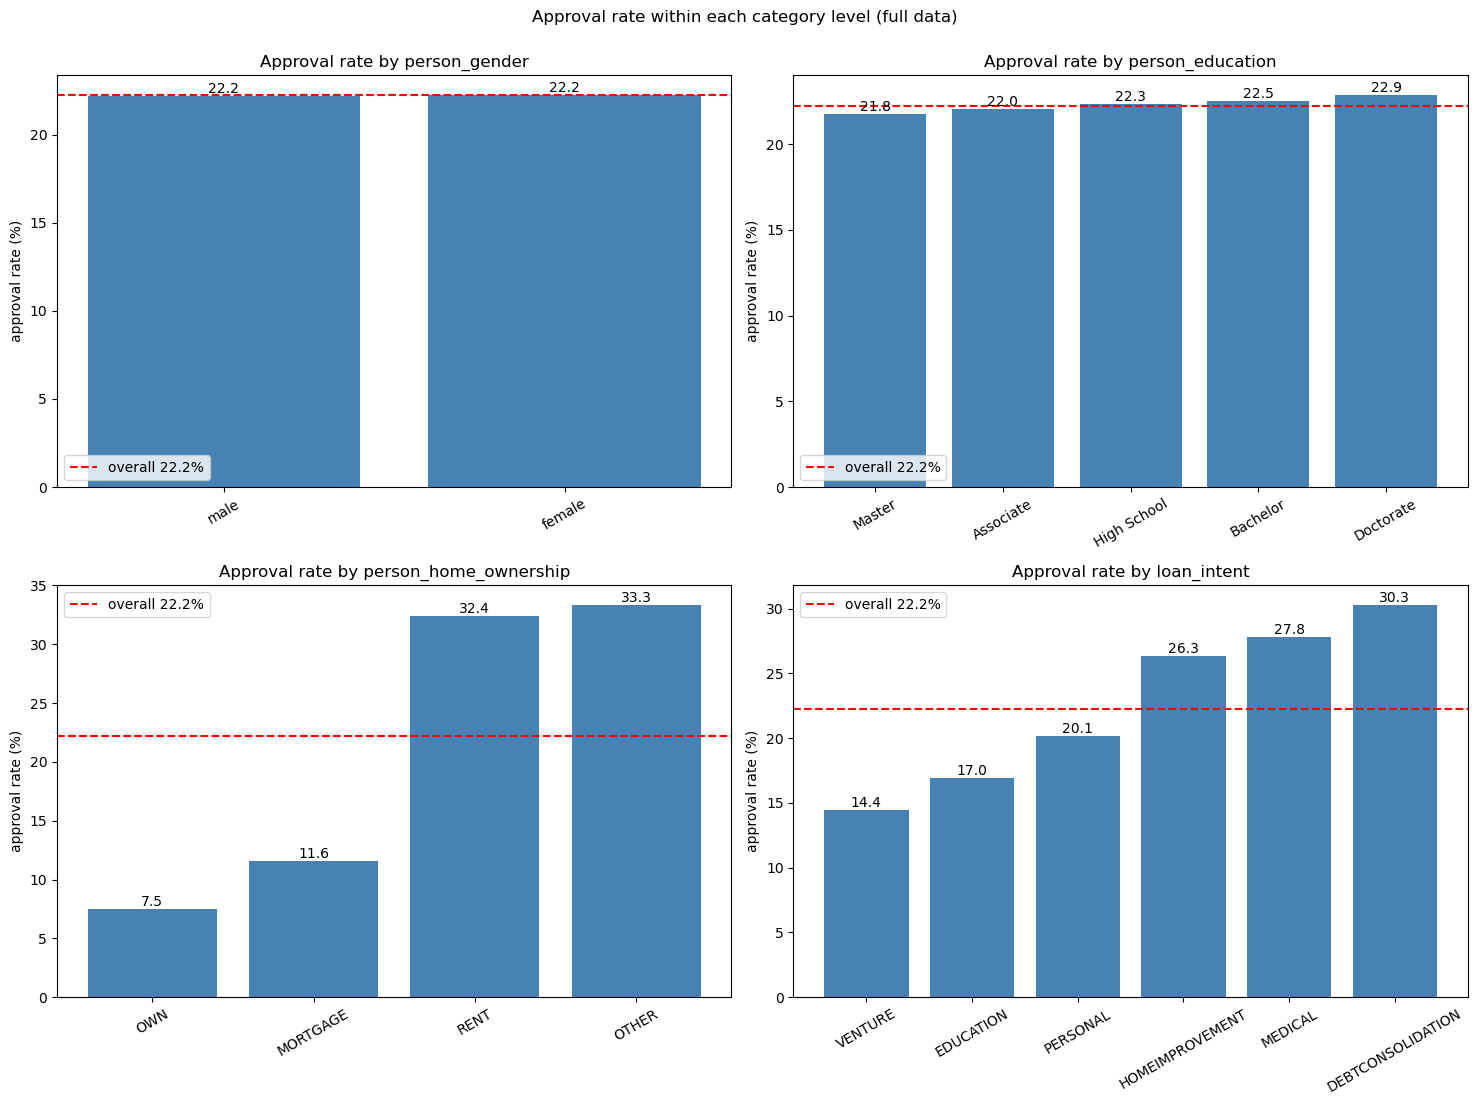

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
overall = df["loan_status"].mean() * 100

for ax, c in zip(axes.flat, cats):
    rate = df.groupby(c)["loan_status"].mean().mul(100).sort_values()
    bars = ax.bar(rate.index.astype(str), rate.values, color="steelblue")
    ax.axhline(overall, color="red", linestyle="--", label=f"overall {overall:.1f}%")
    ax.bar_label(bars, fmt="%.1f")
    ax.set_title(f"Approval rate by {c}")
    ax.set_ylabel("approval rate (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

fig.suptitle("Approval rate within each category level (full data)", y=1.0)
fig.tight_layout()
plt.show()

### What the subgroups reveal

- **Gender** — male and female are essentially identical (both ~22.2% approval, r_income ≈ -0.14, r_loan% ≈ 0.38). Gender explains nothing.
- **Education** — every level sits at ~22% with near-constant correlations. Education explains nothing either. *(Both match their non-significance in the regression above.)*
- **Home ownership** — the big driver. Approval rate swings from **OWN ~7.5%** and **MORTGAGE ~11.6%** up to **RENT ~32.4%**. The relationship *strength* also changes: within MORTGAGE the income correlation nearly vanishes (-0.042) and leverage weakens (0.124), while within RENT leverage is much stronger (0.507).
- **Loan intent** — strong spread in baseline rate: **VENTURE ~14%** and **EDUCATION ~17%** at the low end, **DEBTCONSOLIDATION ~30%** at the high end.

**Bottom line.** The pooled pattern is **not** an artifact of lumping groups together — *within every subgroup* income stays negative, loan-to-income stays positive, and credit score stays ~zero (no sign flips). But **home ownership and loan intent shift the baseline approval rate a lot** (and home ownership changes the strength of the income/leverage effects), which is why controlling for them shrank income's coefficient. Gender and education are irrelevant here.

# What else did we overlook?

Two things we never examined: the `previous_loan_defaults_on_file` column, and the numeric features
outside our chosen three. Both turn out to matter a lot.

## 1. The perfect separator: `previous_loan_defaults_on_file`

In [18]:
ct = pd.crosstab(df["previous_loan_defaults_on_file"], df["loan_status"], margins=True)
print(ct, "\n")
print("Approval % by previous default:")
print(df.groupby("previous_loan_defaults_on_file")["loan_status"].mean().mul(100).round(2))

loan_status                         0      1    All
previous_loan_defaults_on_file                     
No                              12142  10000  22142
Yes                             22858      0  22858
All                             35000  10000  45000 

Approval % by previous default:
previous_loan_defaults_on_file
No     45.16
Yes     0.00
Name: loan_status, dtype: float64


**Every `loan_status == 1` (approved) has "No" previous default — not a single applicant with a prior
default is ever approved.** So the rule "previous default = Yes ⇒ not approved" holds with 100% certainty
across all 22,858 such rows — a sensible hard-rejection rule.

This is **perfect separation**, not a mere correlation. It's why a logistic regression that includes this
column fails to converge (its coefficient is driven toward −∞, reported as something like −24 with a
meaningless p ≈ 0.99). Adding it lifts the model's pseudo-R² from ~0.21 to ~0.51. Practically, approval can
only occur among the "No" rows — so every earlier relationship really lives inside that half of the data.

## 2. Other overlooked columns

Pearson correlation of **every** numeric column with `loan_status`, plus a check on whether
`loan_percent_income` is just a re-expression of `loan_amnt / person_income`.

In [19]:
num = df.select_dtypes("number").drop(columns="loan_status")
ranking = num.apply(lambda s: s.corr(df["loan_status"])).round(3).sort_values()   # Pearson
print("Pearson correlation of every numeric column with loan_status:\n")
print(ranking)

ratio = df["loan_amnt"] / df["person_income"]
print("\ncorr(loan_percent_income, loan_amnt / person_income) =",
      round(df["loan_percent_income"].corr(ratio), 4))

Pearson correlation of every numeric column with loan_status:

person_income                -0.136
person_age                   -0.021
person_emp_exp               -0.020
cb_person_cred_hist_length   -0.015
credit_score                 -0.008
loan_amnt                     0.108
loan_int_rate                 0.332
loan_percent_income           0.385
dtype: float64

corr(loan_percent_income, loan_amnt / person_income) = 0.9994


- **`loan_int_rate` is a strong predictor we never looked at** — Pearson r **+0.33**, almost tying `loan_percent_income` (+0.39). Higher rate associates with more approval in this data.
- **`loan_percent_income` ≈ `loan_amnt / person_income`** (correlation **0.9994**). It is a *derived ratio*, not an independent feature — it shares `person_income` as its denominator. So "income is negative" and "loan% is positive" are partly two views of the same quantity. **We drop `loan_amnt` from the model below to avoid this redundancy.**
- The remaining numerics (age, employment experience, credit-history length, loan amount) are all weak (|r| ≤ 0.11).

# Re-run the correlations within the "No previous default" subgroup

Since approval only ever occurs when `previous_loan_defaults_on_file == "No"`, that subgroup is the
**only** population where the outcome actually varies (its approval rate is ~45%, not ~22%). We recompute
the Pearson correlations there — now including `loan_int_rate` — to see each feature's *real* relationship
once the perfect-separator gate is removed.

In [9]:
sub = df[df["previous_loan_defaults_on_file"] == "No"]
feats = ["credit_score", "person_income", "loan_percent_income", "loan_int_rate"]

def corr_p(d, cols):
    out = {}
    for c in cols:
        r, p = stats.pearsonr(d[c], d["loan_status"])
        out[c] = {"pearson_r": round(r, 3), "p_value": p}
    return pd.DataFrame(out).T

print(f"'No previous default' subgroup: n={len(sub)}, approval rate={100*sub['loan_status'].mean():.1f}%\n")
display(corr_p(sub, feats))

cmp = pd.DataFrame({
    "full_data":  [df[f].corr(df["loan_status"]) for f in feats],
    "no_default": [sub[f].corr(sub["loan_status"]) for f in feats],
}, index=feats).round(3)
print("\nPearson r: full data vs 'No previous default' subgroup")
display(cmp)

NameError: name 'df' is not defined

### What changes inside the subgroup

Restricting to the population that can actually be approved makes **every** relationship stronger, and one
of them appears out of nowhere:

- **credit_score: −0.008 → −0.196** (p ≈ 6e-191). It was *null* on the full data only because the
  "Yes-default" people (all not-approved, across the whole credit-score range) were drowning it out.
  **This is the headline: credit score was hidden, not irrelevant** — and it sets up the Simpson's paradox below.
- **person_income: −0.136 → −0.152** (stronger negative).
- **loan_percent_income: +0.385 → +0.417** (stronger positive).
- **loan_int_rate: +0.332 → +0.377** (stronger positive).

**Takeaway.** The previous-default gate was masking real structure; once removed, every relationship is
stronger and highly significant.

# Final result

In [6]:
sub_flip = sub.copy()
sub_flip["approved"] = 1 - sub_flip["loan_status"]   # demonstration: swap 0 <-> 1

feats4 = ["credit_score", "person_income", "loan_percent_income", "loan_int_rate"]
rows = {}
for f in feats4:
    r_orig = sub_flip[f].corr(sub_flip["loan_status"])
    r_flip, p = stats.pearsonr(sub_flip[f], sub_flip["approved"])
    rows[f] = {"r_loan_status": round(r_orig, 3), "r_(approved)": round(r_flip, 3), "p_value": p}
flip_tbl = pd.DataFrame(rows).T
print("Eligible subgroup  (approved = 1 - loan_status):\n")
display(flip_tbl)

vals = flip_tbl["r(approved)"].astype(float)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#27ae60" if v > 0 else "#c0392b" for v in vals]   # green raises approval, red lowers
ax.barh(feats4, vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
for i, v in enumerate(vals):
    ax.text(v + (0.012 if v >= 0 else -0.012), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right")
ax.set_xlim(-0.55, 0.35)
ax.set_xlabel("Pearson r (approved = 1 - loan_status)")
ax.set_title("Eligible subgroup")
plt.show()

NameError: name 'sub' is not defined

### FINAL

| feature |  r | reads as |
|---|---|---|
| **credit_score** | **+0.196** | higher credit score → more approval  |
| **person_income** | **+0.152** | higher income → more approval  |
| **loan_percent_income** | **−0.417** | higher debt-to-income → less approval  |
| **loan_int_rate** | **−0.377** | higher interest rate → less approval  |

